In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [17]:
from google.colab import files

uploaded = files.upload()

Saving Unemployment in India.csv to Unemployment in India (1).csv


In [18]:
df = pd.read_csv("Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [19]:
print("Shape of Dataset:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nNull Values:")
print(df.isnull().sum())

Shape of Dataset:
(768, 7)

Data Types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

Null Values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [20]:
print(df.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [21]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [22]:
df.dropna(inplace=True)

print("New Shape:", df.shape)

New Shape: (740, 7)


In [23]:
df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


/tmp/ipykernel_8693/1378797363.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [24]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [25]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

region_avg.sort_values(ascending=False).head(10)

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


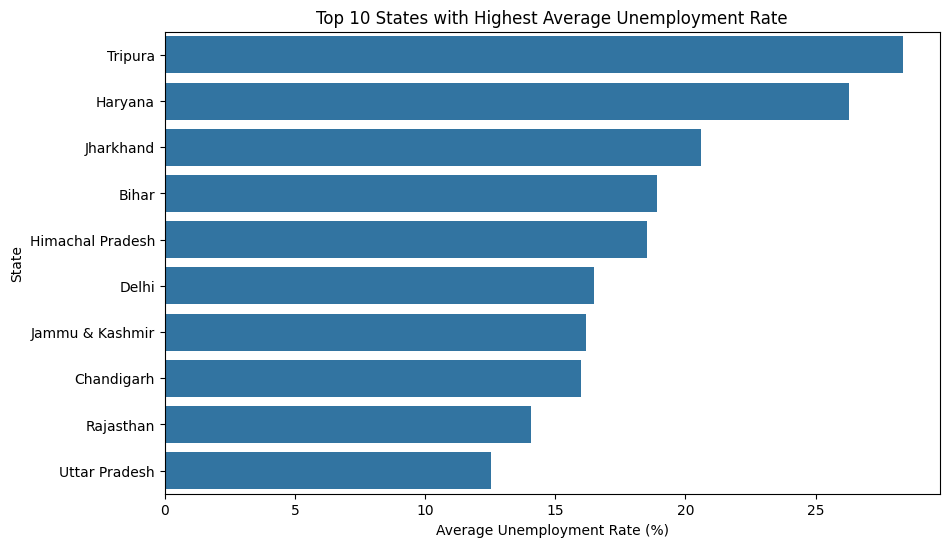

In [26]:
top10 = region_avg.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.show()

In [27]:
df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

monthly_avg

,Estimated Unemployment Rate (%)
Month,
1,9.950755
2,9.964717
3,10.700577
4,23.641569
5,16.646190
6,10.553462
7,9.033889
8,9.637925
9,9.051731


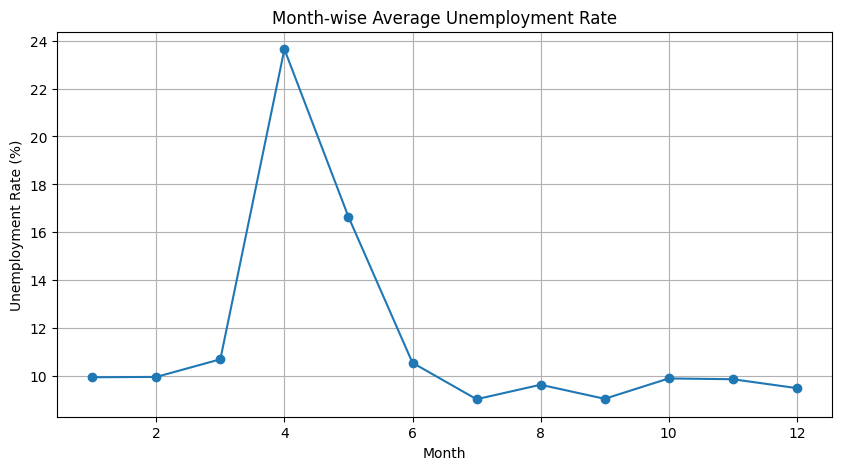

In [28]:
plt.figure(figsize=(10,5))

monthly_avg.plot(
    marker='o'
)

plt.title("Month-wise Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")

plt.grid(True)
plt.show()

In [30]:
states = ['Maharashtra','Karnataka','Tamil Nadu']

filtered = df[df['Region'].isin(states)]

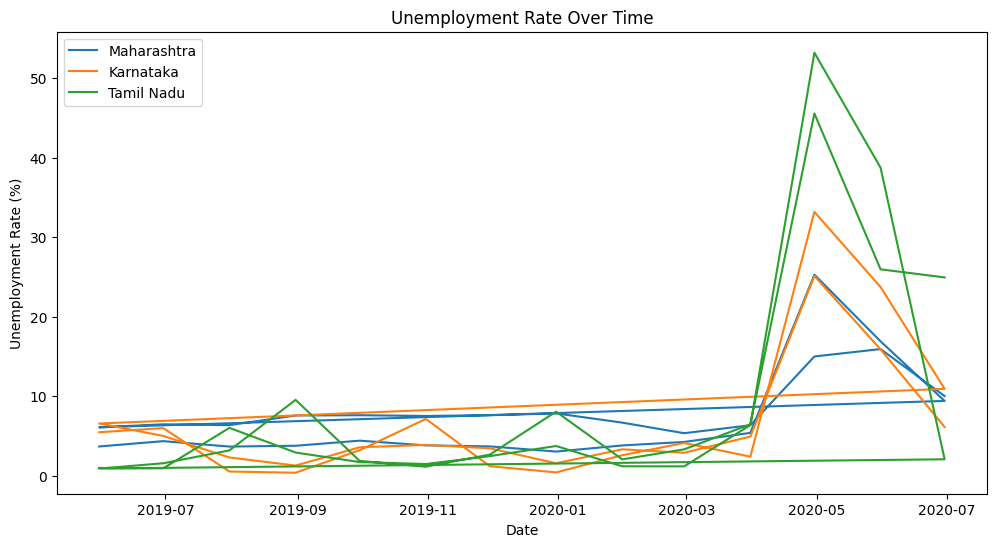

In [31]:
plt.figure(figsize=(12,6))

for state in states:
    temp = filtered[filtered['Region']==state]

    plt.plot(
        temp['Date'],
        temp['Estimated Unemployment Rate (%)'],
        label=state
    )

plt.legend()
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.show()

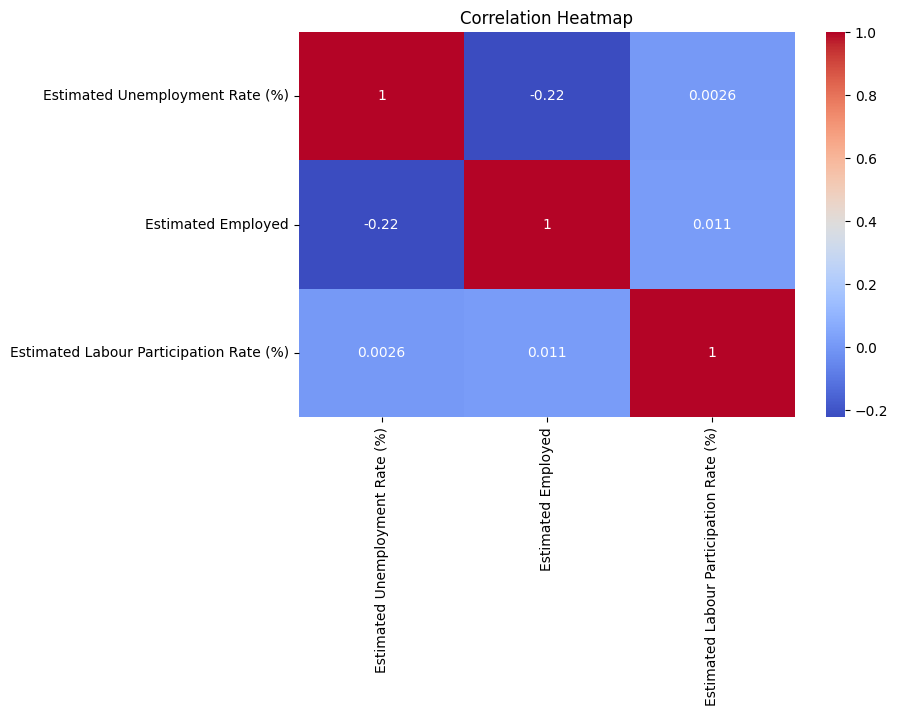

In [32]:
corr = df[[
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [33]:
covid_date = '2020-03-01'

pre_covid = df[df['Date'] < covid_date]

post_covid = df[df['Date'] >= covid_date]

In [34]:
pre_mean = pre_covid['Estimated Unemployment Rate (%)'].mean()

post_mean = post_covid['Estimated Unemployment Rate (%)'].mean()

print("Pre-COVID Average:", round(pre_mean,2))
print("Post-COVID Average:", round(post_mean,2))

Pre-COVID Average: 9.51
Post-COVID Average: 17.77


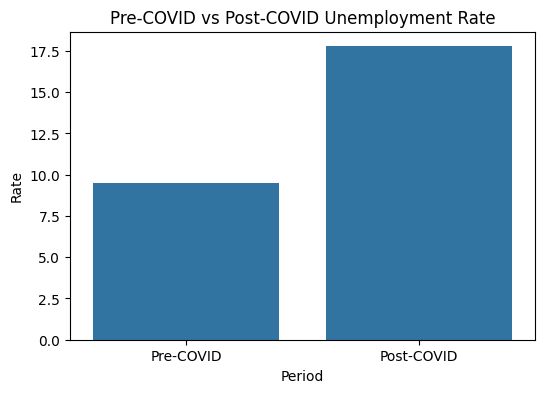

In [35]:
comparison = pd.DataFrame({
    'Period':['Pre-COVID','Post-COVID'],
    'Rate':[pre_mean, post_mean]
})

plt.figure(figsize=(6,4))

sns.barplot(
    x='Period',
    y='Rate',
    data=comparison
)

plt.title("Pre-COVID vs Post-COVID Unemployment Rate")

plt.show()